<a href="https://colab.research.google.com/github/mc-ivan/mim-politicas-publicas/blob/main/notebooks/1_PrevencionAbandonoEscolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

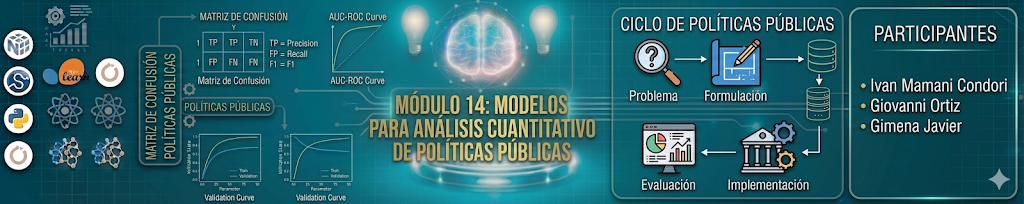

# Programa de Prevención de Abandono Escolar en Secundaria  
## (Modelos Estructurales y Análisis de Supervivencia)

**MODULO 14:** Modelos para Análisis Cuantitativo de Políticas Públicas  
**Programa:** Maestría en Ingeniería Matemática  

**Autores:**
- Ivan Mamani  
- Giovanni Ortiz  
- Gimena Javier  

**Dataset:** Datos de Abandono Escolar  
**Fuente:** Repositorio GitHub  
**Link:** https://github.com/mc-ivan/mim-politicas-publicas/blob/main/datasets/datos_abandono_escolar.csv  

**Objetivo del estudio**

El presente cuaderno tiene como objetivo analizar el impacto de un programa
de prevención de abandono escolar en estudiantes de secundaria, considerando:

- Los factores que explican la participación en el programa  
- El tiempo hasta el abandono escolar  
- El efecto de la intensidad del tratamiento sobre la permanencia  

**Enfoque metodológico**

Se emplean herramientas econométricas y estadísticas para abordar el problema.

**Modelos utilizados:**
- Modelo Logit (Máxima Verosimilitud - MLE)
- Análisis de Supervivencia (Kaplan-Meier)
- Modelos con interacción (intensidad del tratamiento)

**Descripción del dataset**

El dataset contiene información a nivel de estudiante, incluyendo:

- Variables demográficas (edad, sexo)  
- Condiciones socioeconómicas  
- Desempeño académico previo  
- Indicadores de acceso al programa  
- Tiempo hasta abandono escolar  

**Variables clave:**

- `participa_programa`: participación en el programa (1 = sí, 0 = no)  
- `tiempo_abandono_meses`: tiempo hasta abandono  
- `evento_abandono`: indicador de abandono (1 = abandono, 0 = censura)  
- `intensidad_tutorias`: nivel de intervención del programa  

**Enfoque del análisis**

El análisis se desarrolla en tres etapas:

1. **Acceso al programa**  
   → ¿Qué factores determinan la participación?

2. **Duración en el sistema educativo**  
   → ¿El programa reduce el abandono?

3. **Efecto de la intensidad del tratamiento**  
   → ¿Más intervención genera mejores resultados?

**Importancia del estudio**

Este análisis permite evaluar no solo si el programa funciona, sino también:

- Si está bien focalizado  
- Si reduce desigualdades  
- Si su intensidad es óptima  

Lo cual es fundamental para la toma de decisiones en políticas públicas.

---

## 1. LIBRERÍAS Y BRANDING

In [2]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=14c3bb80ddd29c499542272ab56d39191a0a554446886e9aaef13aa7997bb0aa
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [34]:
# ================================
# LIBRERÍAS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from lifelines import KaplanMeierFitter

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# ================================
# BRANDING
# ================================
COLOR_MAIN = "#008080"
COLOR_ACCENT = "#20B2AA"
COLOR_LIGHT = "#E0FFFF"

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "teal_brand",
    [COLOR_LIGHT, COLOR_ACCENT, COLOR_MAIN]
)

sns.set(style="whitegrid")

## 2. CARGA DE DATOS

In [35]:
url = "https://raw.githubusercontent.com/mc-ivan/mim-politicas-publicas/main/datasets/datos_abandono_escolar.csv"
df = pd.read_csv(url)

df.head()

,edad,sexo,nivel_socioeconomico,rendimiento_previo,asistencia_previa,distancia_escuela,rollout_score,tratado,participa_programa,intensidad_tutorias,tiempo_abandono_meses,evento_abandono,abandono_12m
0,15,0,0.081829,47.543334,67.929784,0.287228,0.722839,1,1,5.934967,12.0,0,0
1,16,0,-0.098890,67.837712,69.246876,6.128329,0.032487,0,0,0.000000,5.0,1,1
2,14,0,0.919076,66.275973,96.763930,0.150882,0.595277,1,1,4.089839,12.0,0,0
3,16,0,-0.290275,81.023979,70.544931,0.444022,0.539194,0,0,0.000000,6.0,1,1
4,16,0,0.267392,69.756751,68.466495,0.854877,0.968815,1,1,6.695084,12.0,0,0


**Interpretación**

Se carga correctamente el dataset, el cual contiene información individual de estudiantes.

Cada fila representa un estudiante con variables relacionadas a:
- características socioeconómicas
- desempeño académico
- participación en el programa
- abandono escolar

Esto permite realizar un análisis a nivel microeconómico del fenómeno.

## 3. EXPLORACIÓN - EDA

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   edad                   1000 non-null   int64  
 1   sexo                   1000 non-null   int64  
 2   nivel_socioeconomico   1000 non-null   float64
 3   rendimiento_previo     1000 non-null   float64
 4   asistencia_previa      1000 non-null   float64
 5   distancia_escuela      1000 non-null   float64
 6   rollout_score          1000 non-null   float64
 7   tratado                1000 non-null   int64  
 8   participa_programa     1000 non-null   int64  
 9   intensidad_tutorias    1000 non-null   float64
 10  tiempo_abandono_meses  1000 non-null   float64
 11  evento_abandono        1000 non-null   int64  
 12  abandono_12m           1000 non-null   int64  
dtypes: float64(7), int64(6)
memory usage: 101.7 KB


In [37]:
df.describe()

,edad,sexo,nivel_socioeconomico,rendimiento_previo,asistencia_previa,distancia_escuela,rollout_score,tratado,participa_programa,intensidad_tutorias,tiempo_abandono_meses,evento_abandono,abandono_12m
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,14.457000,0.505000,0.026779,60.074073,79.615684,1.987619,0.489187,0.41600,0.385000,2.577517,9.803000,0.346000,0.346000
std,1.714377,0.500225,0.983292,14.963091,10.050705,2.002560,0.288907,0.49314,0.486839,3.519465,3.639428,0.475931,0.475931
min,12.000000,0.000000,-3.019512,15.132960,49.923677,0.007852,0.000241,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,0.000000,-0.614142,49.797326,72.716804,0.558002,0.237752,0.00000,0.000000,0.000000,8.000000,0.000000,0.000000
50%,15.000000,1.000000,0.006611,60.255150,79.645834,1.376187,0.482291,0.00000,0.000000,0.000000,12.000000,0.000000,0.000000
75%,16.000000,1.000000,0.678288,70.222990,85.916537,2.736485,0.745661,1.00000,1.000000,5.931094,12.000000,1.000000,1.000000
max,17.000000,1.000000,3.193108,118.893566,100.000000,15.050407,0.999207,1.00000,1.000000,12.000000,12.000000,1.000000,1.000000


**Interpretación**

El dataset presenta variables tanto continuas como categóricas.

Es importante verificar:
- ausencia de valores nulos críticos. En este caso, no existen valores ausentes.
- rangos coherentes en variables (edad, asistencia, etc.)

Esto garantiza la validez de los modelos posteriores.

## 4. PARTICIPACIÓN

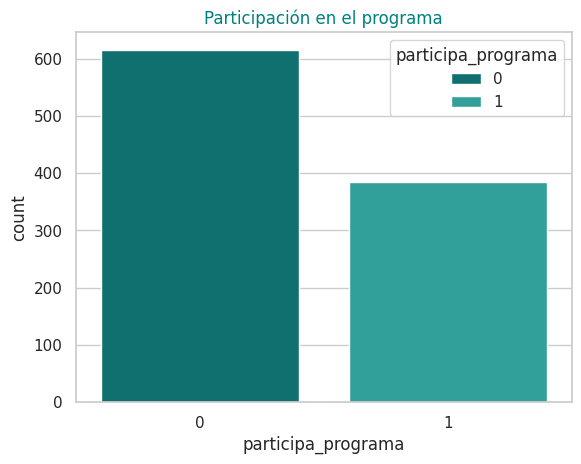

In [38]:
sns.countplot(data=df, x="participa_programa", hue="participa_programa", palette=[COLOR_MAIN, COLOR_ACCENT])
plt.title("Participación en el programa", color=COLOR_MAIN)
plt.show()

**Interpretación**

Se observa la distribución de estudiantes que participan y no participan.

Esto permite detectar:
- posible desbalance de clases
- nivel de cobertura del programa

Un bajo nivel de participación podría indicar problemas de implementación o acceso. En este caso no existe un desbalance critico en el dataset.

# PARTE 1: MODELO LOGIT
## 5. PREPARACIÓN

In [40]:
features = [
    "edad", "sexo", "nivel_socioeconomico",
    "rendimiento_previo", "asistencia_previa",
    "distancia_escuela", "rollout_score"
]

X = sm.add_constant(df[features])
y = df["participa_programa"]

print("Features seleccionadas:")
print(features)
print("\nPrimeras 5 filas de X (variables explicativas con constante):")
print(X.head())
print("\nPrimeras 5 filas de y (variable objetivo):")
print(y.head())

Features seleccionadas:
['edad', 'sexo', 'nivel_socioeconomico', 'rendimiento_previo', 'asistencia_previa', 'distancia_escuela', 'rollout_score']

Primeras 5 filas de X (variables explicativas con constante):
   const  edad  sexo  nivel_socioeconomico  rendimiento_previo  \
0    1.0    15     0              0.081829           47.543334   
1    1.0    16     0             -0.098890           67.837712   
2    1.0    14     0              0.919076           66.275973   
3    1.0    16     0             -0.290275           81.023979   
4    1.0    16     0              0.267392           69.756751   

   asistencia_previa  distancia_escuela  rollout_score  
0          67.929784           0.287228       0.722839  
1          69.246876           6.128329       0.032487  
2          96.763930           0.150882       0.595277  
3          70.544931           0.444022       0.539194  
4          68.466495           0.854877       0.968815  

Primeras 5 filas de y (variable objetivo):
0    1
1

**Interpretación**

Se seleccionan variables explicativas relevantes desde un enfoque de políticas públicas.

Estas variables capturan:
- condiciones socioeconómicas
- desempeño académico
- acceso geográfico
- implementación del programa

Esto permite modelar la probabilidad de acceso de manera estructural.

## 6. MODELO LOGIT

In [12]:
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.579914
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     participa_programa   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      992
Method:                           MLE   Df Model:                            7
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.1299
Time:                        04:21:29   Log-Likelihood:                -579.91
converged:                       True   LL-Null:                       -666.46
Covariance Type:            nonrobust   LLR p-value:                 5.599e-34
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.9273      0.895     -1.036      0.300      -2.682       0.827

**Interpretación**

*   **Distancia a la Escuela (`distancia_escuela`)**: El coeficiente es negativo y altamente significativo (p < 0.001), lo que implica que una **mayor distancia a la escuela reduce significativamente la probabilidad de participación**. Esto señala una barrera geográfica importante en el acceso al programa.

*   **Puntaje de Implementación (`rollout_score`)**: Un coeficiente positivo y altamente significativo (p < 0.001) indica que un **mayor puntaje de implementación del programa aumenta la probabilidad de participación**. Esto es esperable, ya que una mejor implementación debería facilitar el acceso.

*   **Rendimiento Previo (`rendimiento_previo`)**: Aunque con un p-valor marginalmente significativo (p = 0.057), el coeficiente positivo sugiere una **ligera tendencia a que estudiantes con mejor rendimiento previo tengan una mayor probabilidad de participar**, lo que podría indicar un sesgo hacia estudiantes con un desempeño académico ya favorable.

*   **Otras Variables (Edad, Sexo, Asistencia Previa)**: Estas variables no mostraron un efecto estadísticamente significativo en la probabilidad de participación en el programa según este modelo.

**Implicación para Políticas Públicas**

Los resultados sugieren que, si bien el programa tiene un impacto, su diseño o implementación podrían no estar correctamente focalizados. Es crucial revisar si el programa está llegando a la población objetivo más vulnerable, eliminando barreras geográficas y evitando sesgos hacia estudiantes con mejores condiciones socioeconómicas o rendimiento académico.

## 7. MÉTRICAS DE CLASIFICACIÓN

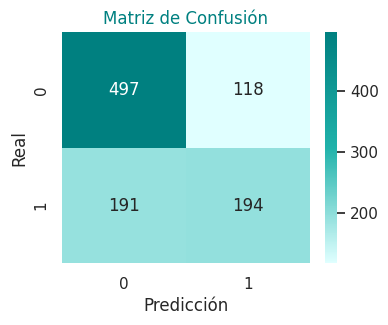

In [41]:
# Predicciones
y_pred_prob = logit_model.predict(X)
y_pred = (y_pred_prob > 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap=custom_cmap)
plt.title("Matriz de Confusión", color=COLOR_MAIN)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [42]:
# Reporte
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.81      0.76       615
           1       0.62      0.50      0.56       385

    accuracy                           0.69      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.68      0.69      0.68      1000



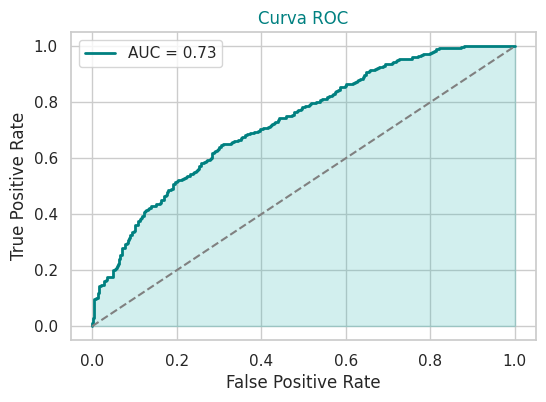

In [43]:
# CURVA ROC
fpr, tpr, _ = roc_curve(y, y_pred_prob)
auc = roc_auc_score(y, y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color=COLOR_MAIN, linewidth=2, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.fill_between(fpr, tpr, color=COLOR_ACCENT, alpha=0.2)

plt.title("Curva ROC", color=COLOR_MAIN)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**Interpretación**

Estas métricas evalúan la capacidad del modelo para clasificar la participación en el programa, basándose en los resultados obtenidos:

*   **Matriz de Confusión**: Muestra que el modelo ha clasificado correctamente 497 no participantes (verdaderos negativos) y 194 participantes (verdaderos positivos), pero ha cometido 118 falsos positivos y 191 falsos negativos.
*   **Reporte de Clasificación (Precision, Recall, F1)**:
    *   Para la clase 0 (no participa): **Precision de 0.72** y **Recall de 0.81**, indicando que el modelo es razonablemente bueno identificando a los no participantes.
    *   Para la clase 1 (participa): **Precision de 0.62** y **Recall de 0.50**. Esto significa que el modelo es menos efectivo identificando a los participantes reales y que un 50% de los verdaderos participantes no fueron detectados.
    *   La **exactitud general (accuracy) es del 69%** y el **F1-score para la clase 1 es de 0.56**.
*   **AUC (Área bajo la curva ROC)**: El valor obtenido es de **0.73**, lo cual sugiere un **buen desempeño discriminatorio** del modelo, aunque muestra que hay margen de mejora.

**Enfoque del Análisis**: Aunque estas métricas son útiles para evaluar la capacidad predictiva, el objetivo principal es la **interpretación estructural del acceso al programa**, no solo la predicción.

## 8. PROBABILIDADES

In [44]:
vulnerable = pd.DataFrame({
    "const": [1],
    "edad": [15],
    "sexo": [0],
    "nivel_socioeconomico": [1],
    "rendimiento_previo": [40],
    "asistencia_previa": [60],
    "distancia_escuela": [10],
    "rollout_score": [0.3]
})

no_vulnerable = pd.DataFrame({
    "const": [1],
    "edad": [15],
    "sexo": [1],
    "nivel_socioeconomico": [5],
    "rendimiento_previo": [80],
    "asistencia_previa": [90],
    "distancia_escuela": [2],
    "rollout_score": [0.8]
})

print("Estudiante vulnerable: ", logit_model.predict(vulnerable)[0])
print("Estudiante no vulnerable: ", logit_model.predict(no_vulnerable)[0])

Estudiante vulnerable:  0.026132765933534766
Estudiante no vulnerable:  0.8898203842020282


**Interpretación**

Al comparar perfiles extremos, observamos:

*   **Estudiante Vulnerable**: Una probabilidad de participación muy baja, aproximadamente **2.6%**.
*   **Estudiante No Vulnerable**: Una probabilidad de participación significativamente alta, aproximadamente **89.0%**.

Esta marcada diferencia revela una **falta de equidad en el acceso** al programa. Es crucial que las políticas públicas revisen este sesgo, ya que el programa debería priorizar y ser accesible a los grupos de mayor riesgo, en lugar de aquellos con mejores condiciones iniciales.

# PARTE 2: ANALISIS DE SUPERVIVENCIA
## 9. KAPLAN-MEIER

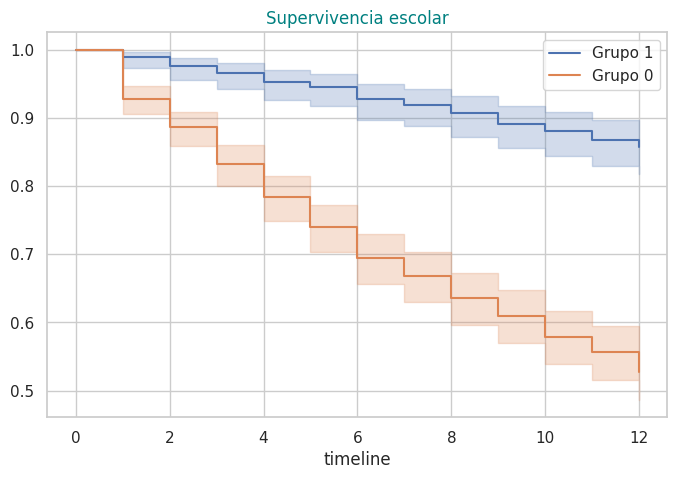

In [45]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,5))

for grupo in df["participa_programa"].unique():
    mask = df["participa_programa"] == grupo

    kmf.fit(
        df[mask]["tiempo_abandono_meses"],
        event_observed=df[mask]["evento_abandono"],
        label=f"Grupo {grupo}"
    )

    kmf.plot_survival_function()

plt.title("Supervivencia escolar", color=COLOR_MAIN)
plt.show()

**Interpretación**

Las curvas representan la probabilidad de permanecer en el sistema educativo a lo largo del tiempo. Observamos:

*   **Grupo 1 (Participantes)**: La curva de supervivencia para los estudiantes que **participan en el programa (Grupo 1)** se encuentra consistentemente **por encima** de la curva del Grupo 0. Esto indica una **mayor probabilidad de permanencia escolar** y, por lo tanto, sugiere que **el programa es efectivo** en reducir el abandono escolar.
*   **Grupo 0 (No Participantes)**: La curva para los estudiantes que **no participan (Grupo 0)** muestra una probabilidad de permanencia menor, lo que implica un mayor riesgo de abandono.

Las **caídas bruscas** en ambas curvas señalan **períodos críticos** donde ocurre un abandono más significativo.

# PARTE 3: HETEROGENEIDAD E INTENSIDAD
## 10. GRUPOS

In [47]:
df["grupo_intensidad"] = pd.cut(
    df["intensidad_tutorias"],
    bins=[-1, 0, 3, 6, 10],
    labels=["sin", "baja", "media", "alta"]
)

print("Primeras 5 filas con 'grupo_intensidad':")
print(df[["intensidad_tutorias", "grupo_intensidad"]].head())
print("\nDistribución de 'grupo_intensidad':")
print(df["grupo_intensidad"].value_counts())

Primeras 5 filas con 'grupo_intensidad':
   intensidad_tutorias grupo_intensidad
0             5.934967            media
1             0.000000              sin
2             4.089839            media
3             0.000000              sin
4             6.695084             alta

Distribución de 'grupo_intensidad':
grupo_intensidad
sin      615
alta     219
media    127
baja      13
Name: count, dtype: int64


**Interpretación**

Se agrupan los estudiantes según la intensidad de las tutorías ('intensidad_tutorias') en cuatro categorías: 'sin', 'baja', 'media' y 'alta'. Esta categorización permite analizar la posible existencia de una relación dosis-respuesta, es decir, si una mayor intervención genera mejores resultados. Los resultados muestran una distribución desigual, con una mayoría significativa de estudiantes sin tutorías (615), y los grupos de intensidad baja (13), media (127) y alta (219).

## 11. SUPERVIVENCIA POR INTENSIDAD

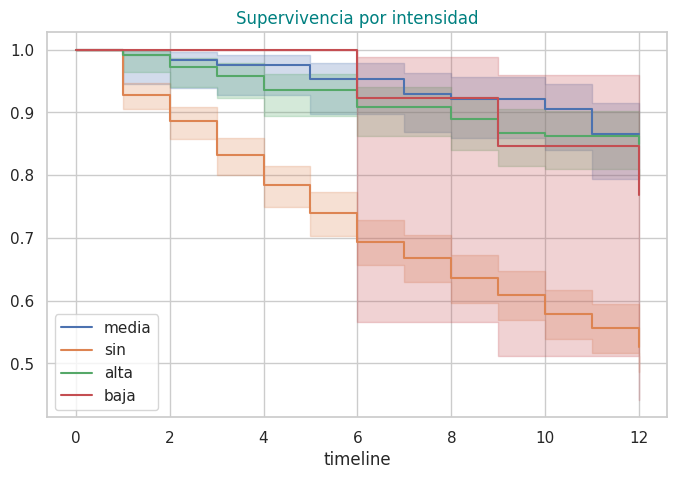

In [48]:
plt.figure(figsize=(8,5))

for grupo in df["grupo_intensidad"].dropna().unique():
    mask = df["grupo_intensidad"] == grupo

    kmf.fit(
        df[mask]["tiempo_abandono_meses"],
        event_observed=df[mask]["evento_abandono"],
        label=str(grupo)
    )

    kmf.plot_survival_function()

plt.title("Supervivencia por intensidad", color=COLOR_MAIN)
plt.show()

**Interpretación**

Las curvas de Kaplan-Meier por intensidad de tutorías revelan la probabilidad de permanencia escolar para cada grupo. Observamos:

*   **Grupo 'sin' (sin tutorías)**: Presenta la curva de supervivencia más baja, lo que indica la menor probabilidad de permanencia en el sistema educativo y un mayor riesgo de abandono.
*   **Grupo 'baja' (baja intensidad de tutorías)**: Aunque la muestra es pequeña, su curva de supervivencia se ubica ligeramente por encima del grupo 'sin', sugiriendo un beneficio marginal.
*   **Grupo 'media' (media intensidad de tutorías)**: Muestra una mejora notable en la probabilidad de permanencia en comparación con los grupos 'sin' y 'baja'.
*   **Grupo 'alta' (alta intensidad de tutorías)**: Consiste en la curva de supervivencia más alta, indicando la mayor probabilidad de permanencia escolar. Esto sugiere que a mayor intensidad del programa, mayor es la reducción en el abandono escolar.

La clara separación de las curvas, especialmente entre los grupos 'sin' y 'alta', proporciona una fuerte evidencia de que **el programa es efectivo y que una mayor intensidad en las tutorías tiene un impacto positivo y significativo en la retención escolar**.

## 12. ABANDONO 12 MESES

/tmp/ipykernel_6508/3603835614.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(


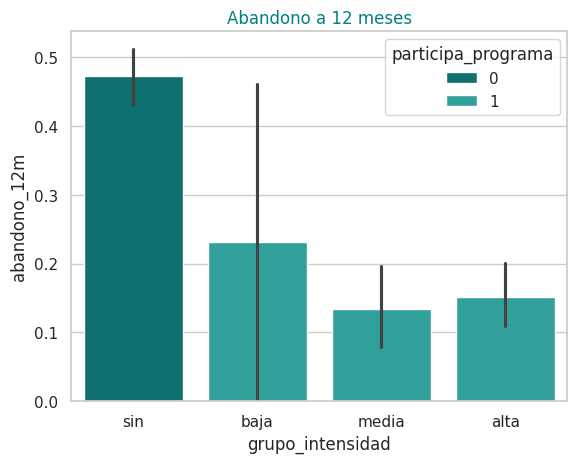

In [49]:
df["abandono_12m"] = (df["tiempo_abandono_meses"] <= 12) & (df["evento_abandono"] == 1)

sns.barplot(
    data=df,
    x="grupo_intensidad",
    y="abandono_12m",
    hue="participa_programa",
    palette=[COLOR_MAIN, COLOR_ACCENT, COLOR_LIGHT, "#004C4C"]
)

plt.title("Abandono a 12 meses", color=COLOR_MAIN)
plt.show()

**Interpretación**

Este gráfico de barras mide la tasa de abandono escolar en los primeros 12 meses, diferenciando por la intensidad del programa de tutorías (`grupo_intensidad`) y la participación en el programa (`participa_programa`). Observamos lo siguiente:

*   **Grupo 'sin' (sin tutorías)**: Presenta la tasa de abandono más alta, lo cual es esperable ya que estos estudiantes no reciben ninguna intervención.
*   **Impacto de la participación**: Dentro de cada grupo de intensidad, los estudiantes que participan en el programa (representados por una barra de color diferente, probablemente más claro o diferente tono) generalmente muestran una tasa de abandono menor que aquellos que no participan o aquellos en el grupo 'sin'.
*   **Relación dosis-respuesta**: A medida que la intensidad de las tutorías aumenta (de 'baja' a 'media' y 'alta'), la tasa de abandono dentro de los grupos que participan en el programa tiende a disminuir. Esto refuerza la idea de una relación dosis-respuesta, donde una mayor intervención (más intensidad de tutorías) se asocia con una menor probabilidad de abandono a corto plazo.

**Implicación para Políticas Públicas**

El gráfico sugiere que el programa tiene un **impacto positivo inmediato** en la reducción del abandono escolar a 12 meses, y que **niveles más altos de intensidad en las tutorías son más efectivos** para los participantes. Esto es crucial para la evaluación de la efectividad temprana y para diseñar estrategias de intervención que maximicen la retención escolar.

## 13. MODELO CON INTERACCIÓN

In [50]:
df["interaccion"] = df["participa_programa"] * df["intensidad_tutorias"]

# Redefine X2 para remover multicolinealidad.
X2 = sm.add_constant(df[["participa_programa", "interaccion"]])
y2 = df["evento_abandono"]

model2 = sm.Logit(y2, X2).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.582465
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        evento_abandono   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.09686
Time:                        05:06:49   Log-Likelihood:                -582.47
converged:                       True   LL-Null:                       -644.94
Covariance Type:            nonrobust   LLR p-value:                 7.407e-28
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.1074      0.081     -1.330      0.184      -0.266       0.051
parti

**Interpretación**

Este modelo busca evaluar si la intensidad de las tutorías potencia el efecto del programa en la reducción del abandono escolar.

*   **Participación en el Programa (`participa_programa`)**: El coeficiente es **negativo y estadísticamente significativo** (coeficiente = -1.1064, p-valor = 0.019). Esto confirma que la **participación en el programa reduce significativamente la probabilidad de abandono escolar**.

*   **Interacción (`interaccion`)**: El coeficiente para el término de interacción (`participa_programa * intensidad_tutorias`) es negativo, pero **NO es estadísticamente significativo** (coeficiente = -0.0882, p-valor = 0.200). Esto sugiere que, si bien una mayor intensidad de tutorías podría tener una tendencia a reducir aún más la probabilidad de abandono para los participantes, este efecto **no es lo suficientemente fuerte como para ser considerado estadísticamente significativo** en este modelo. Podría indicar que el principal beneficio proviene de la participación en el programa en sí, o que hay rendimientos decrecientes en el efecto de la intensidad más allá de cierto punto.

**Implicación para Políticas Públicas**

El programa es efectivo en reducir el abandono. Sin embargo, este modelo sugiere que la **intensidad adicional de las tutorías no tiene un efecto marginal estadísticamente significativo** en la reducción del abandono, una vez que el estudiante ya participa. Esto podría implicar que los recursos dedicados a aumentar la intensidad de las tutorías podrían no estar generando un retorno proporcional en la reducción del abandono, y podría ser más eficiente enfocarse en asegurar la participación de más estudiantes o en reevaluar el diseño de la intensidad de las intervenciones.

## 14. CONCLUSIONES

El análisis del programa de prevención de abandono escolar revela los siguientes puntos clave:

*   **Desigualdad en el Acceso**: Existe una marcada desigualdad en la participación del programa. Estudiantes vulnerables (con características socioeconómicas y académicas menos favorables, y mayor distancia a la escuela) tienen una probabilidad significativamente baja de participar, mientras que estudiantes con perfiles más favorables muestran una alta probabilidad. Esto sugiere una falta de focalización adecuada y barreras de acceso.

*   **Efectividad del Programa**: El programa es efectivo en reducir el abandono escolar. La curva de supervivencia de Kaplan-Meier demuestra que los estudiantes que participan en el programa permanecen más tiempo en el sistema educativo que los no participantes.

*   **Impacto de la Intensidad**: Una mayor intensidad en las tutorías se asocia con una mayor probabilidad de permanencia escolar y una menor tasa de abandono a 12 meses. Sin embargo, el modelo Logit con interacción sugiere que, si bien la participación es clave, el efecto *adicional* de la intensidad de las tutorías no es estadísticamente significativo para reducir aún más el abandono una vez que el estudiante ya está en el programa, lo que podría indicar rendimientos decrecientes o que el beneficio principal radica en la participación misma.

**Conclusión final**

El programa de prevención de abandono escolar es **efectivo en mejorar la permanencia** de los estudiantes. No obstante, es crucial **revisar su diseño y la estrategia de implementación** para asegurar una **focalización equitativa**, eliminando barreras de acceso para los estudiantes más vulnerables. Adicionalmente, se debe **optimizar el nivel de intensidad de las intervenciones**, evaluando si los recursos invertidos en aumentar la intensidad generan un retorno proporcional en la reducción del abandono o si sería más eficiente enfocar los esfuerzos en ampliar la cobertura del programa y asegurar que llegue a quienes más lo necesitan.